##### Importing inportant librarries


In [137]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix,precision_score,recall_score,classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score


##### Loading the dataset

In [2]:
df=pd.read_csv('../data/loan_dataset.csv')

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


- As Loan_ID has no importance in the process of Approval or Rejection ,we are directly dropping this column


In [4]:
df.drop(labels='Loan_ID',inplace=True,axis=1,errors='raise')

In [5]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


##### Seperate the target(y) and input_variable(X)
- here Loan_Status is the target variable(y)
- and df.columns except Loan_Status are the inputs
- inputvariable(X) df without target column

In [6]:
y=df['Loan_Status']

In [7]:
y.head()

0    Y
1    N
2    Y
3    Y
4    Y
Name: Loan_Status, dtype: object

In [8]:
X=df.drop(labels='Loan_Status',errors='raise',axis=1)

In [9]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban


In [10]:
df['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

##### Train test split
- here the data is very less ,compared to real world
- As we already know dataset is imbalanced ,we need to split stratifiedly
- What is this stratify??
- if training data have more datapoints in class_1,and few data points in class_0,our model may tend to biased towards dominant class
- So if we split stratifiedly ,we can prevent this by splitting data in such a way both training and testing data have similar ratio of no.of Datapoints of class_1 to class_0
- This confirms ,our model do not show any bias towards one of the classes 


In [11]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [12]:
print(df.shape)

(614, 12)


In [13]:
print(X_train .shape)
print(y_train.shape)

(491, 11)
(491,)


In [14]:
print(X_test.shape)
print(y_test.shape)


(123, 11)
(123,)


In [15]:
y_test.value_counts()



Loan_Status
Y    85
N    38
Name: count, dtype: int64

In [16]:
temp=85/38
print(temp)

2.236842105263158


In [17]:
y_train.value_counts()

Loan_Status
Y    337
N    154
Name: count, dtype: int64

In [18]:
temp2=337/154
print(temp2)

2.188311688311688


In [19]:
X_train.isnull().sum()

Gender               11
Married               3
Dependents            8
Education             0
Self_Employed        27
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           20
Loan_Amount_Term     12
Credit_History       43
Property_Area         0
dtype: int64

In [20]:
for col in X_train.columns:
    if col not in ['ApplicantIncome','CoapplicantIncome','LoanAmount']:
        print(col,X_train[col].unique())
        print(X_train[col].value_counts())
        print("--------")

Gender ['Male' 'Female' nan]
Gender
Male      393
Female     87
Name: count, dtype: int64
--------
Married ['No' 'Yes' nan]
Married
Yes    319
No     169
Name: count, dtype: int64
--------
Dependents ['0' '1' '2' nan '3+']
Dependents
0     276
1      85
2      83
3+     39
Name: count, dtype: int64
--------
Education ['Graduate' 'Not Graduate']
Education
Graduate        380
Not Graduate    111
Name: count, dtype: int64
--------
Self_Employed ['No' 'Yes' nan]
Self_Employed
No     398
Yes     66
Name: count, dtype: int64
--------
Loan_Amount_Term [360. 180.  nan  84. 300. 240.  60. 480.  12. 120.  36.]
Loan_Amount_Term
360.0    409
180.0     35
480.0     11
300.0     10
240.0      4
84.0       3
60.0       2
120.0      2
36.0       2
12.0       1
Name: count, dtype: int64
--------
Credit_History [ 1.  0. nan]
Credit_History
1.0    381
0.0     67
Name: count, dtype: int64
--------
Property_Area ['Urban' 'Semiurban' 'Rural']
Property_Area
Semiurban    184
Urban        162
Rural        145


In [21]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 154 to 354
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             480 non-null    object 
 1   Married            488 non-null    object 
 2   Dependents         483 non-null    object 
 3   Education          491 non-null    object 
 4   Self_Employed      464 non-null    object 
 5   ApplicantIncome    491 non-null    int64  
 6   CoapplicantIncome  491 non-null    float64
 7   LoanAmount         471 non-null    float64
 8   Loan_Amount_Term   479 non-null    float64
 9   Credit_History     448 non-null    float64
 10  Property_Area      491 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 46.0+ KB


In [22]:
X_train['Dependents'] = X_train['Dependents'].replace(to_replace='3+', value='3')

In [23]:
X_test['Dependents'] = X_test['Dependents'].replace('3+','3')


In [24]:
X_test['Dependents'].unique()

array(['0', '1', '3', nan, '2'], dtype=object)

In [25]:
X_train['Dependents'].unique()

array(['0', '1', '2', nan, '3'], dtype=object)

##### Changing datatype of dependents Column
- intilaly its a string ,we are converting it into float in both training and test data

In [26]:
X_train['Dependents'] = X_train['Dependents'].astype('float64')


In [27]:
X_test['Dependents']=X_test['Dependents'].astype('float64')

##### Handling missing values
- for categorical features ,mode is good
- for numerical feature ,median imputation is best ,,as median is robuts to outliers


In [28]:
Gender_mode=X_train['Gender'].mode()[0]
Married_mode=X_train['Married'].mode()[0]
Self_Employed_mode=X_train['Self_Employed'].mode()[0]
Dependents_mode=X_train['Dependents'].mode()[0]
Credit_History_mode=X_train['Credit_History'].mode()[0]
Loan_Amount_Term_mode=X_train['Loan_Amount_Term'].mode()[0]

LoanAmount_median=X_train['LoanAmount'].median()


##### Target variable 

In [29]:
Loan_Status_mode=y_train.mode()[0]

In [30]:
print(Dependents_mode)

0.0


In [31]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 491 entries, 154 to 354
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             480 non-null    object 
 1   Married            488 non-null    object 
 2   Dependents         483 non-null    float64
 3   Education          491 non-null    object 
 4   Self_Employed      464 non-null    object 
 5   ApplicantIncome    491 non-null    int64  
 6   CoapplicantIncome  491 non-null    float64
 7   LoanAmount         471 non-null    float64
 8   Loan_Amount_Term   479 non-null    float64
 9   Credit_History     448 non-null    float64
 10  Property_Area      491 non-null    object 
dtypes: float64(5), int64(1), object(5)
memory usage: 46.0+ KB


##### Filling missing values
- In both training and testing data ,we need to impute our values computed from training data to ensure there is no data leakage 
- And then it will be robust to new unknown datapoints also


In [32]:
X_train['Gender']=X_train['Gender'].fillna(Gender_mode)
X_train['Married']=X_train['Married'].fillna(Married_mode)
X_train['Dependents']=X_train['Dependents'].fillna(Dependents_mode)
X_train['Self_Employed']=X_train['Self_Employed'].fillna(Self_Employed_mode)

X_train['Credit_History']=X_train['Credit_History'].fillna(Credit_History_mode)
X_train['Loan_Amount_Term']=X_train['Loan_Amount_Term'].fillna(Loan_Amount_Term_mode)



X_train['LoanAmount'] = X_train['LoanAmount'].fillna(LoanAmount_median)

In [33]:
y_train=y_train.fillna(Loan_Status_mode)

In [34]:
X_train.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
154,Male,No,0.0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban
239,Male,Yes,1.0,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban
448,Male,Yes,2.0,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural
471,Male,Yes,1.0,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural
273,Male,Yes,0.0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban
71,Male,Yes,2.0,Not Graduate,Yes,1875,1875.0,97.0,360.0,1.0,Semiurban
590,Male,Yes,0.0,Graduate,No,3000,3416.0,56.0,180.0,1.0,Semiurban
187,Male,Yes,0.0,Graduate,No,2383,2138.0,58.0,360.0,1.0,Rural
404,Female,No,0.0,Graduate,Yes,7441,0.0,194.0,360.0,1.0,Rural
159,Male,Yes,0.0,Graduate,No,4583,5625.0,255.0,360.0,1.0,Semiurban


In [35]:
X_train.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [36]:
X_test['Gender']=X_test['Gender'].fillna(Gender_mode)
X_test['Married']=X_test['Married'].fillna(Married_mode)
X_test['Self_Employed']=X_test['Self_Employed'].fillna(Self_Employed_mode)
X_test['Dependents']=X_test['Dependents'].fillna(Dependents_mode)
X_test['Credit_History']=X_test['Credit_History'].fillna(Credit_History_mode)
X_test['Loan_Amount_Term']=X_test['Loan_Amount_Term'].fillna(Loan_Amount_Term_mode)



X_test['LoanAmount'] = X_test['LoanAmount'].fillna(LoanAmount_median)

In [37]:
X_test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
150,Male,No,0.0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural
559,Female,Yes,0.0,Graduate,No,4180,2306.0,182.0,360.0,1.0,Semiurban
598,Male,Yes,0.0,Graduate,Yes,9963,0.0,180.0,360.0,1.0,Rural
235,Male,Yes,1.0,Graduate,No,5500,1260.0,170.0,360.0,1.0,Rural
145,Female,Yes,0.0,Graduate,No,2330,4486.0,100.0,360.0,1.0,Semiurban


In [38]:
X_test.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64

In [39]:
X_test.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
150,Male,No,0.0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural
559,Female,Yes,0.0,Graduate,No,4180,2306.0,182.0,360.0,1.0,Semiurban
598,Male,Yes,0.0,Graduate,Yes,9963,0.0,180.0,360.0,1.0,Rural
235,Male,Yes,1.0,Graduate,No,5500,1260.0,170.0,360.0,1.0,Rural
145,Female,Yes,0.0,Graduate,No,2330,4486.0,100.0,360.0,1.0,Semiurban
191,Male,No,0.0,Graduate,No,12000,0.0,164.0,360.0,1.0,Semiurban
557,Male,Yes,3.0,Graduate,Yes,10139,0.0,260.0,360.0,1.0,Semiurban
470,Male,Yes,1.0,Graduate,Yes,3450,2079.0,162.0,360.0,1.0,Semiurban
88,Male,No,0.0,Graduate,No,8566,0.0,210.0,360.0,1.0,Urban
386,Male,No,0.0,Not Graduate,No,2346,1600.0,132.0,360.0,1.0,Semiurban


##### Creating our useful columns
- TotalIncome
- ApplicantIncome + CoapplicantIncome

- Loan_Income_Ratio
- ( LoanAmount * 1000 ) /TotalIncome

In [40]:
X_train['TotalIncome'] = X_train['ApplicantIncome'] + X_train['CoapplicantIncome']
X_train['Loan_Income_Ratio']=(X_train['LoanAmount']*1000)/X_train['TotalIncome']

In [41]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
154,Male,No,0.0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,3254.0,15.365704
239,Male,Yes,1.0,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,3315.0,28.959276
448,Male,Yes,2.0,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,5050.0,29.702970
471,Male,Yes,1.0,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural,4153.0,27.209246
273,Male,Yes,0.0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban,4843.0,30.972538


In [42]:
X_test['TotalIncome'] = X_test['ApplicantIncome'] + X_test['CoapplicantIncome']
X_test['Loan_Income_Ratio']=(X_test['LoanAmount']*1000)/X_test['TotalIncome']


In [43]:
print(X_train.shape)
print(X_test.shape)

(491, 13)
(123, 13)


##### Encoding Step
- As our model cant understand Strings like 'Male','Female','Yes','No' and so on 
- We usually convert them into numbers
- Here ,if the feature is binary ,we will map it directly using binary digits 1 and 0
- if column having more than 2 values ,going to do ONeHotEncoding
- This is for categorical variables

In [44]:
X_train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'TotalIncome',
       'Loan_Income_Ratio'],
      dtype='object')

##### binary variables 
- NO NEED TO CREATE NEW COLUMNS,WE CAN JUST MODIFY COLUMN BY REPLACING WITH BINARY DIGITS
- 'Gender' --> Male_(!) and Female(0)
- 'Married' --> Yes(1) and No(0)
- 'Education' --> Graduate(1) and Not Graduate(0)
- 'Loan_Status'---> Yes(1) and No(0)



##### Gender
- Male and __Male are different here
- So we need to clean the column first ,and then map

In [45]:
X_train['Gender'].tail(10)

360    Female
383      Male
297    Female
447      Male
117      Male
222      Male
349      Male
26       Male
96     Female
354    Female
Name: Gender, dtype: object

In [46]:
X_train['Gender'] = X_train['Gender'].str.strip()
X_train['Gender'] = X_train['Gender'].map({'Male':1,'Female':0})


In [47]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
154,1,No,0.0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,3254.0,15.365704
239,1,Yes,1.0,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,3315.0,28.959276
448,1,Yes,2.0,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,5050.0,29.702970
471,1,Yes,1.0,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural,4153.0,27.209246
273,1,Yes,0.0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban,4843.0,30.972538


In [48]:
X_test['Gender'] = X_test['Gender'].str.strip()
X_test['Gender'] = X_test['Gender'].map({'Male':1,'Female':0})

In [49]:
X_test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
150,1,No,0.0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural,6277.0,18.798789
559,0,Yes,0.0,Graduate,No,4180,2306.0,182.0,360.0,1.0,Semiurban,6486.0,28.060438
598,1,Yes,0.0,Graduate,Yes,9963,0.0,180.0,360.0,1.0,Rural,9963.0,18.066847
235,1,Yes,1.0,Graduate,No,5500,1260.0,170.0,360.0,1.0,Rural,6760.0,25.147929
145,0,Yes,0.0,Graduate,No,2330,4486.0,100.0,360.0,1.0,Semiurban,6816.0,14.671362


##### Married 
- Yes  ---> 1

- No   ---> 0

- clean the column
- replace with binary digits

In [50]:
X_train['Married'].head(10)

154     No
239    Yes
448    Yes
471    Yes
273    Yes
71     Yes
590    Yes
187    Yes
404     No
159    Yes
Name: Married, dtype: object

In [51]:
X_train['Married'] = X_train['Married'].str.strip()
X_train['Married'] = X_train['Married'].map({'Yes':1,'No':0})

In [52]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
154,1,0,0.0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban,3254.0,15.365704
239,1,1,1.0,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban,3315.0,28.959276
448,1,1,2.0,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural,5050.0,29.702970
471,1,1,1.0,Not Graduate,No,2653,1500.0,113.0,180.0,0.0,Rural,4153.0,27.209246
273,1,1,0.0,Graduate,No,2620,2223.0,150.0,360.0,1.0,Semiurban,4843.0,30.972538


In [53]:
X_test['Married'] = X_test['Married'].str.strip()
X_test['Married'] = X_test['Married'].map({'Yes':1,'No':0})

In [54]:
X_test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
150,1,0,0.0,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural,6277.0,18.798789
559,0,1,0.0,Graduate,No,4180,2306.0,182.0,360.0,1.0,Semiurban,6486.0,28.060438
598,1,1,0.0,Graduate,Yes,9963,0.0,180.0,360.0,1.0,Rural,9963.0,18.066847
235,1,1,1.0,Graduate,No,5500,1260.0,170.0,360.0,1.0,Rural,6760.0,25.147929
145,0,1,0.0,Graduate,No,2330,4486.0,100.0,360.0,1.0,Semiurban,6816.0,14.671362


##### Education
- Graduate ---> 1
- Not Graduate ---> 0

In [55]:
X_train['Education'].head(10)

154        Graduate
239        Graduate
448        Graduate
471    Not Graduate
273        Graduate
71     Not Graduate
590        Graduate
187        Graduate
404        Graduate
159        Graduate
Name: Education, dtype: object

In [56]:
X_train['Education'] = X_train['Education'].str.strip()
X_train['Education'] = X_train['Education'].map({'Graduate':1,'Not Graduate':0})

In [57]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
154,1,0,0.0,1,No,3254,0.0,50.0,360.0,1.0,Urban,3254.0,15.365704
239,1,1,1.0,1,No,3315,0.0,96.0,360.0,1.0,Semiurban,3315.0,28.959276
448,1,1,2.0,1,No,3340,1710.0,150.0,360.0,0.0,Rural,5050.0,29.702970
471,1,1,1.0,0,No,2653,1500.0,113.0,180.0,0.0,Rural,4153.0,27.209246
273,1,1,0.0,1,No,2620,2223.0,150.0,360.0,1.0,Semiurban,4843.0,30.972538


In [58]:
X_test['Education'] = X_test['Education'].str.strip()
X_test['Education'] = X_test['Education'].map({'Graduate':1,'Not Graduate':0})

In [59]:
X_test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
150,1,0,0.0,1,No,6277,0.0,118.0,360.0,0.0,Rural,6277.0,18.798789
559,0,1,0.0,1,No,4180,2306.0,182.0,360.0,1.0,Semiurban,6486.0,28.060438
598,1,1,0.0,1,Yes,9963,0.0,180.0,360.0,1.0,Rural,9963.0,18.066847
235,1,1,1.0,1,No,5500,1260.0,170.0,360.0,1.0,Rural,6760.0,25.147929
145,0,1,0.0,1,No,2330,4486.0,100.0,360.0,1.0,Semiurban,6816.0,14.671362


##### Self_Employed
- Yes ---> 1
- No ----> 0


In [60]:
X_train['Self_Employed'].head(10)

154     No
239     No
448     No
471     No
273     No
71     Yes
590     No
187     No
404    Yes
159     No
Name: Self_Employed, dtype: object

In [61]:
X_train['Self_Employed'] = X_train['Self_Employed'].str.strip()
X_train['Self_Employed'] = X_train['Self_Employed'].map({'Yes':1,'No':0})


In [62]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
154,1,0,0.0,1,0,3254,0.0,50.0,360.0,1.0,Urban,3254.0,15.365704
239,1,1,1.0,1,0,3315,0.0,96.0,360.0,1.0,Semiurban,3315.0,28.959276
448,1,1,2.0,1,0,3340,1710.0,150.0,360.0,0.0,Rural,5050.0,29.702970
471,1,1,1.0,0,0,2653,1500.0,113.0,180.0,0.0,Rural,4153.0,27.209246
273,1,1,0.0,1,0,2620,2223.0,150.0,360.0,1.0,Semiurban,4843.0,30.972538


In [63]:
X_test['Self_Employed'] = X_test['Self_Employed'].str.strip()
X_test['Self_Employed'] = X_test['Self_Employed'].map({'Yes':1,'No':0})

In [64]:
X_test.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Loan_Income_Ratio
150,1,0,0.0,1,0,6277,0.0,118.0,360.0,0.0,Rural,6277.0,18.798789
559,0,1,0.0,1,0,4180,2306.0,182.0,360.0,1.0,Semiurban,6486.0,28.060438
598,1,1,0.0,1,1,9963,0.0,180.0,360.0,1.0,Rural,9963.0,18.066847
235,1,1,1.0,1,0,5500,1260.0,170.0,360.0,1.0,Rural,6760.0,25.147929
145,0,1,0.0,1,0,2330,4486.0,100.0,360.0,1.0,Semiurban,6816.0,14.671362


In [65]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 123 entries, 150 to 373
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             123 non-null    int64  
 1   Married            123 non-null    int64  
 2   Dependents         123 non-null    float64
 3   Education          123 non-null    int64  
 4   Self_Employed      123 non-null    int64  
 5   ApplicantIncome    123 non-null    int64  
 6   CoapplicantIncome  123 non-null    float64
 7   LoanAmount         123 non-null    float64
 8   Loan_Amount_Term   123 non-null    float64
 9   Credit_History     123 non-null    float64
 10  Property_Area      123 non-null    object 
 11  TotalIncome        123 non-null    float64
 12  Loan_Income_Ratio  123 non-null    float64
dtypes: float64(7), int64(5), object(1)
memory usage: 13.5+ KB


##### Encoding for target variable in both train and test data
- Binary Encoding
- Y ----> 1
- N ----> 0

In [66]:
y_train.head()

154    Y
239    Y
448    N
471    N
273    Y
Name: Loan_Status, dtype: object

In [67]:


y_train= y_train.str.strip()
y_train = y_train.map({'Y':1,'N':0})

In [68]:
y_train.head()

154    1
239    1
448    0
471    0
273    1
Name: Loan_Status, dtype: int64

In [69]:
y_test= y_test.str.strip()
y_test = y_test.map({'Y':1,'N':0})

In [70]:
y_test.head()

150    0
559    1
598    1
235    1
145    1
Name: Loan_Status, dtype: int64

##### OneHotEncoding
- Depemdents
- Property_Area
- Loan_Amount_Term

In [71]:
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


##### fit on train data

In [72]:
encoder.fit(X_train[['Dependents','Property_Area','Loan_Amount_Term']])


,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [73]:
encoded_train = encoder.transform(X_train[['Dependents','Property_Area','Loan_Amount_Term']])


In [74]:
encoded_train_df=pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out())
encoded_train_df


,Dependents_0.0,Dependents_1.0,Dependents_2.0,Dependents_3.0,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Amount_Term_12.0,Loan_Amount_Term_36.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
486,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
487,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
488,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
489,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [75]:
encoded_test = encoder.transform(X_test[['Dependents','Property_Area','Loan_Amount_Term']])


In [76]:
encoded_test_df=pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out())
encoded_test_df

,Dependents_0.0,Dependents_1.0,Dependents_2.0,Dependents_3.0,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Amount_Term_12.0,Loan_Amount_Term_36.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
119,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
120,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
121,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


##### Dropping the Old Columns
- We have OneHotEncoded Dependents into 4 categories,so we need to drop our previous Dependents column
- In the same way ,need to drop Property_Area and Loan_Amount_Term
- Dependents ----> 4 
- Property_Area ----> 3
- Loan_Amount_Term ----> 10

In [77]:
X_train.drop(labels=['Dependents','Property_Area','Loan_Amount_Term'],inplace=True,axis=1)

In [78]:
X_train.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,TotalIncome,Loan_Income_Ratio
154,1,0,1,0,3254,0.0,50.0,1.0,3254.0,15.365704
239,1,1,1,0,3315,0.0,96.0,1.0,3315.0,28.959276
448,1,1,1,0,3340,1710.0,150.0,0.0,5050.0,29.702970
471,1,1,0,0,2653,1500.0,113.0,0.0,4153.0,27.209246
273,1,1,1,0,2620,2223.0,150.0,1.0,4843.0,30.972538


In [79]:
X_test.drop(labels=['Dependents','Property_Area','Loan_Amount_Term'],inplace=True,axis=1)

In [80]:
X_test.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,TotalIncome,Loan_Income_Ratio
150,1,0,1,0,6277,0.0,118.0,0.0,6277.0,18.798789
559,0,1,1,0,4180,2306.0,182.0,1.0,6486.0,28.060438
598,1,1,1,1,9963,0.0,180.0,1.0,9963.0,18.066847
235,1,1,1,0,5500,1260.0,170.0,1.0,6760.0,25.147929
145,0,1,1,0,2330,4486.0,100.0,1.0,6816.0,14.671362


##### Our Final Dataframes for both train and test
- Drop that old variables before OneHotEncoding
- Computed OneHotEncoding columns
- Convert them into dataframes
- Append both of them to create final_dataframe

In [81]:
X_train = X_train.reset_index(drop=True)
encoded_train_df= encoded_train_df.reset_index(drop=True)


In [82]:
X_train.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,TotalIncome,Loan_Income_Ratio
0,1,0,1,0,3254,0.0,50.0,1.0,3254.0,15.365704
1,1,1,1,0,3315,0.0,96.0,1.0,3315.0,28.959276
2,1,1,1,0,3340,1710.0,150.0,0.0,5050.0,29.702970
3,1,1,0,0,2653,1500.0,113.0,0.0,4153.0,27.209246
4,1,1,1,0,2620,2223.0,150.0,1.0,4843.0,30.972538


In [83]:
encoded_train_df.head()

,Dependents_0.0,Dependents_1.0,Dependents_2.0,Dependents_3.0,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban,Loan_Amount_Term_12.0,Loan_Amount_Term_36.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [84]:
X_final_train=pd.concat([X_train,encoded_train_df],axis=1)

In [85]:
X_test = X_test.reset_index(drop=True)
encoded_test_df = encoded_test_df.reset_index(drop=True)


In [86]:
X_final_test=pd.concat([X_test,encoded_test_df],axis=1)

##### Check no of Final Datapoints 
- As our train and test data have the indices different and not in order 
- If We directly concat ,due to difference in indices there is chance our data may form duplicates 
- So to avoid that,we used reset_index and and then conact ,both sepearte datframes
- Done this for both Training and testing data

In [87]:
len(df)==len(X_final_train)+len(X_final_test)

True

In [88]:
print(X_train.shape)
print(X_test.shape)


(491, 10)
(123, 10)


#### FEATURE SCALING
- We need to scale continuous numerical features
- our numerical features have different ranges 
- There may be chance of model be biased towards features with larger values
- So we need to scale those with Z_Score
- which is nothing but StandardSclaer 


In [89]:
### Create  scaler object
scaler = StandardScaler()
##  z = (x - u) / s


In [90]:
num_features = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'TotalIncome',
    'Loan_Income_Ratio'
]
## these are our numerical non dummy continuous features which requires scaling

##### Fit is only for training data
##### To avoid data leakage ,we dont compute fit for testing data
##### Transform is for both train and test data

In [91]:
scaler.fit(X_final_train[num_features])


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [92]:
X_final_train[num_features] = scaler.transform(X_final_train[num_features])


In [93]:
X_final_train.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,TotalIncome,Loan_Income_Ratio,...,Loan_Amount_Term_12.0,Loan_Amount_Term_36.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0
0,1,0,1,0,-0.352802,-0.563228,-1.131588,1.0,-0.575168,-1.017208,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,1,1,0,-0.343346,-0.563228,-0.592309,1.0,-0.566044,0.664623,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,1,1,0,-0.339471,0.050405,0.040758,0.0,-0.306544,0.756635,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,1,0,0,-0.445963,-0.024953,-0.393010,0.0,-0.440706,0.448105,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,1,1,0,-0.451078,0.234495,0.040758,1.0,-0.337505,0.913709,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [94]:
X_final_test[num_features] = scaler.transform(X_final_test[num_features])


In [95]:
X_final_test.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Credit_History,TotalIncome,Loan_Income_Ratio,...,Loan_Amount_Term_12.0,Loan_Amount_Term_36.0,Loan_Amount_Term_60.0,Loan_Amount_Term_84.0,Loan_Amount_Term_120.0,Loan_Amount_Term_180.0,Loan_Amount_Term_240.0,Loan_Amount_Term_300.0,Loan_Amount_Term_360.0,Loan_Amount_Term_480.0
0,1,0,1,0,0.115793,-0.563228,-0.334393,0.0,-0.123025,-0.592458,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0,1,1,0,-0.209263,0.264279,0.415908,1.0,-0.091765,0.553417,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1,1,1,1,0.687159,-0.563228,0.392461,1.0,0.428282,-0.683016,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1,1,1,0,-0.004650,-0.111077,0.275227,1.0,-0.050783,0.193074,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,1,1,0,-0.496031,1.046572,-0.545415,1.0,-0.042408,-1.103114,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [96]:
X_final_train[num_features].describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,TotalIncome,Loan_Income_Ratio
count,4.910000e+02,4.910000e+02,4.910000e+02,4.910000e+02,4.910000e+02
mean,-6.512102e-17,7.235669e-18,-1.320510e-16,3.979618e-17,1.230064e-16
std,1.001020e+00,1.001020e+00,1.001020e+00,1.001020e+00,1.001020e+00
min,-8.246518e-01,-5.632281e-01,-1.612250e+00,-8.461841e-01,-2.545128e+00
25%,-4.067454e-01,-5.632281e-01,-5.395538e-01,-4.371167e-01,-5.502813e-01
50%,-2.590211e-01,-1.928951e-01,-2.171586e-01,-2.555416e-01,5.081152e-02
75%,4.572821e-02,2.409543e-01,2.166094e-01,6.744973e-02,5.326782e-01
max,1.169859e+01,1.438897e+01,6.488661e+00,1.105312e+01,7.315004e+00


In [97]:
X_final_train.isnull().sum()

Gender                     0
Married                    0
Education                  0
Self_Employed              0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Credit_History             0
TotalIncome                0
Loan_Income_Ratio          0
Dependents_0.0             0
Dependents_1.0             0
Dependents_2.0             0
Dependents_3.0             0
Property_Area_Rural        0
Property_Area_Semiurban    0
Property_Area_Urban        0
Loan_Amount_Term_12.0      0
Loan_Amount_Term_36.0      0
Loan_Amount_Term_60.0      0
Loan_Amount_Term_84.0      0
Loan_Amount_Term_120.0     0
Loan_Amount_Term_180.0     0
Loan_Amount_Term_240.0     0
Loan_Amount_Term_300.0     0
Loan_Amount_Term_360.0     0
Loan_Amount_Term_480.0     0
dtype: int64

In [98]:
X_final_test.isnull().sum()

Gender                     0
Married                    0
Education                  0
Self_Employed              0
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Credit_History             0
TotalIncome                0
Loan_Income_Ratio          0
Dependents_0.0             0
Dependents_1.0             0
Dependents_2.0             0
Dependents_3.0             0
Property_Area_Rural        0
Property_Area_Semiurban    0
Property_Area_Urban        0
Loan_Amount_Term_12.0      0
Loan_Amount_Term_36.0      0
Loan_Amount_Term_60.0      0
Loan_Amount_Term_84.0      0
Loan_Amount_Term_120.0     0
Loan_Amount_Term_180.0     0
Loan_Amount_Term_240.0     0
Loan_Amount_Term_300.0     0
Loan_Amount_Term_360.0     0
Loan_Amount_Term_480.0     0
dtype: int64

In [99]:
y_train.value_counts()


Loan_Status
1    337
0    154
Name: count, dtype: int64

# Model Training

### Logistic Regression

In [100]:
log_model = LogisticRegression()## intialise log_model

In [101]:
log_model.fit(X_final_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

##### Making predictions on testing data

In [102]:
y_pred = log_model.predict(X_final_test)

### Evaluating the model

In [103]:
ac_score=accuracy_score(y_test, y_pred)
ac_score

0.8536585365853658

In [104]:
con_matrix=confusion_matrix(y_test,y_pred)
con_matrix

array([[22, 16],
       [ 2, 83]])

In [105]:
precision=precision_score(y_test,y_pred)
precision

0.8383838383838383

In [106]:
recall=recall_score(y_test,y_pred)
recall

0.9764705882352941

In [107]:
f1=f1_score(y_test,y_pred)
f1

0.9021739130434783

In [108]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.58      0.71        38
           1       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



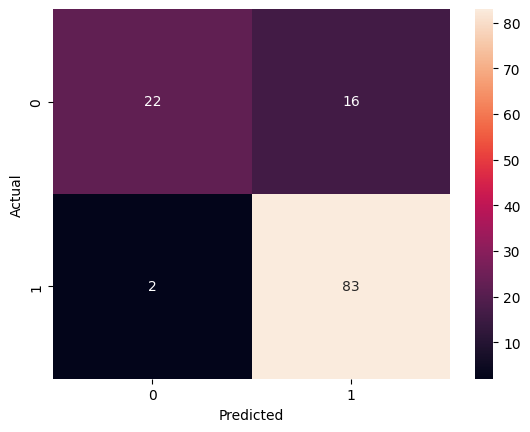

In [ ]:


sns.heatmap(con_matrix, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [111]:
cv_scores = cross_val_score(log_model, X_final_train, y_train, cv=5)
cv_scores

array([0.7979798 , 0.79591837, 0.79591837, 0.78571429, 0.76530612])

In [112]:
cv_scores.mean()

np.float64(0.7881673881673882)

Cross validation was performed using 5-fold K-Fold validation to ensure the model performance is stable across different data splits.

Cross-validation was performed using 5-fold K-Fold validation.  
The Logistic Regression model achieved a mean cross-validation accuracy of approximately 78.8%, indicating stable performance across different data splits.

### Naive Bayes

In [114]:
nb_model = GaussianNB()
nb_model.fit(X_final_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [115]:
y_pred_nb = nb_model.predict(X_final_test)

In [116]:
ac_score_nb=accuracy_score(y_test, y_pred_nb)
ac_score_nb

0.3170731707317073

In [117]:
con_matrix_nb=confusion_matrix(y_test,y_pred_nb)
con_matrix_nb

array([[38,  0],
       [84,  1]])

| Model               | Accuracy | Observation                    |
| ------------------- | -------- | ------------------------------ |
| Logistic Regression | ~0.85    | Good performance               |
| Naive Bayes         | ~0.31    | Poor due to feature dependency |


### k Nearest Neighbour

In [119]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_final_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [120]:
y_pred_knn = knn_model.predict(X_final_test)

In [121]:
ac_score_knn=accuracy_score(y_test, y_pred_knn)
print(ac_score_knn)

con_matrix_knn=confusion_matrix(y_test, y_pred_knn)
print(con_matrix_knn)

0.7886178861788617
[[16 22]
 [ 4 81]]


In [122]:
k_values = range(1,21)
accuracy_scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_final_train, y_train)
    y_pred_knn_hp = knn.predict(X_final_test)
    acc = accuracy_score(y_test, y_pred_knn_hp)
    accuracy_scores.append(acc)

In [126]:
accuracy_scores

[0.7317073170731707,
 0.6666666666666666,
 0.7804878048780488,
 0.8130081300813008,
 0.7886178861788617,
 0.7886178861788617,
 0.7804878048780488,
 0.7804878048780488,
 0.7642276422764228,
 0.7723577235772358,
 0.7317073170731707,
 0.7479674796747967,
 0.7317073170731707,
 0.7479674796747967,
 0.7479674796747967,
 0.7723577235772358,
 0.7398373983739838,
 0.7479674796747967,
 0.7398373983739838,
 0.7398373983739838]

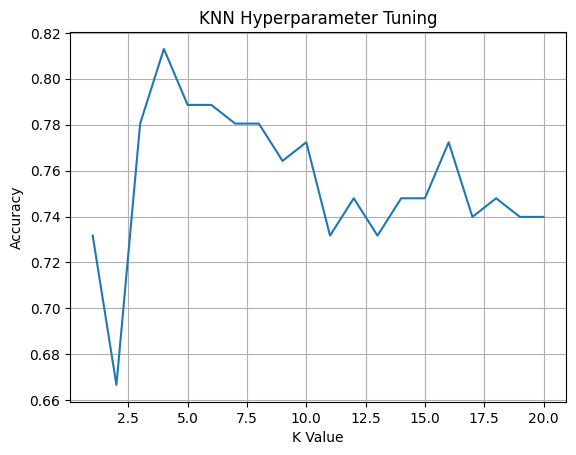

In [131]:
plt.plot(k_values, accuracy_scores)
plt.grid()
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Hyperparameter Tuning")
plt.show()

In [129]:
ac_score_knn_hp=max(accuracy_scores)
print(ac_score_knn_hp)
optimal_k = (accuracy_scores.index(ac_score_knn_hp))+1
print(optimal_k)

0.8130081300813008
4


In [132]:
knn_model = KNeighborsClassifier(n_neighbors=optimal_k)
knn_model.fit(X_final_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [135]:
y_pred_knn_hp_optimal = knn_model.predict(X_final_test)
con_matrix_knn_hp=confusion_matrix(y_test,y_pred_knn_hp_optimal)
acc_knn_hp = accuracy_score(y_test, y_pred_knn_hp_optimal)
acc_knn_hp

0.8130081300813008

In [136]:
print(con_matrix_knn_hp)

[[26 12]
 [11 74]]


In [134]:
print(classification_report(y_test,y_pred_knn_hp_optimal))

              precision    recall  f1-score   support

           0       0.70      0.68      0.69        38
           1       0.86      0.87      0.87        85

    accuracy                           0.81       123
   macro avg       0.78      0.78      0.78       123
weighted avg       0.81      0.81      0.81       123



| Model               | Accuracy |
| ------------------- | -------- |
| Logistic Regression | 0.78     |
| Naive Bayes         | 0.31     |
| KNN (k=4)           | 0.81     |


KNN achieved the best performance among the tested models.

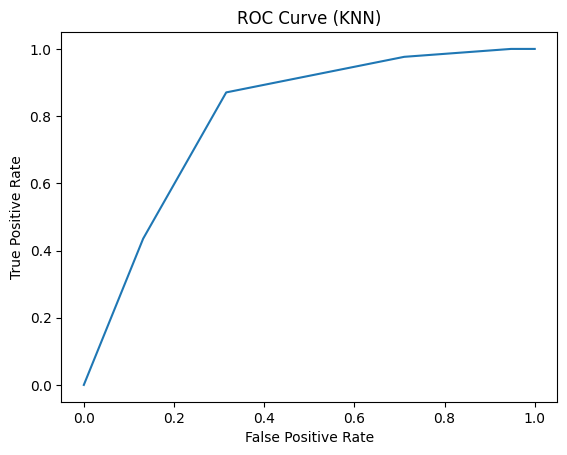

0.8001547987616099

In [138]:
y_prob = knn_model.predict_proba(X_final_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (KNN)")
plt.show()

auc_score

| Model               | Accuracy | AUC  |
| ------------------- | -------- | ---- |
| Logistic Regression | 0.78     | 0.79 |
| Naive Bayes         | 0.31     | 0.50 |
| KNN                 | 0.81     | 0.80 |


higher AUC = better class separation

Among the evaluated models, KNN achieved the highest accuracy (81%)
and a strong ROC-AUC score of 0.80, indicating good ability to
distinguish between eligible and ineligible loan applicants.

#### SAVE THE MODEL

In [139]:
import joblib

In [140]:
joblib.dump(knn_model, "loan_model.pkl")

['loan_model.pkl']

In [141]:
loaded_model = joblib.load("loan_model.pkl")

loaded_model.predict(X_final_test[:5])

array([0, 1, 1, 1, 1])